In [1]:
import os
import pandas as pd
import plotnine as pln

# helper functions

In [2]:
def annotation_df(res, target, x=0.41, y=0.65):
    corr_data = []
    for source in ["viral", "cellular"]:
        for split in ["Pooled Split", "Site Split"]:
            q = '(Source == @source) & (Split == @split)' 
            corr = res.query(q)['R2_score_test'].corr(res.query(q)[target], method='pearson')
            
            corr_data.append({
                'Source': source,
                'Split': split,
                'correlation': corr,
                'label': f"r = {corr:.03f}"
            })

    ann_df = pd.DataFrame(corr_data)
    ann_df[target] = x
    ann_df['R2_score_test'] = ann_df['Source'].map({'cellular': y, 'viral': y+0.05,})
    return ann_df

# Results

In [3]:
lassocv = pd.read_csv('../experiments/res_lassoCV_esm2_650m_v02.csv', index_col=0)
lassocv['Source'] = pd.Categorical(lassocv['Source'], categories=['viral', 'cellular'])

p = ["Pooled Split"]
s = ["Site Split"]
a = ["Pooled Split", "Site Split"]

res = lassocv.query('Split in @p')
res

,Model,Source,Split,Dataset,R2_score_test,cv,RVSM,coverage,coverage_site,coverage_within,prot_length,fractionSD,fractionSD_ranked
0,ESM-2 650M,cellular,Pooled Split,AMIE_PSEAE_Whitehead,0.477524,0.895529,0.684369,0.949133,0.985549,0.963050,346,0.504399,0.489736
1,ESM-2 650M,cellular,Pooled Split,B3VI55_LIPSTSTABLE,0.451530,0.626518,0.596003,0.948633,1.000000,0.948633,439,0.660592,0.751708
2,ESM-2 650M,cellular,Pooled Split,B3VI55_LIPST_Whitehead2015,0.245162,0.542289,0.513957,0.918793,1.000000,0.918793,439,0.749431,0.890661
3,ESM-2 650M,cellular,Pooled Split,BG_STRSQ_hmmerbit,0.412022,0.837254,0.600783,0.349301,1.000000,0.349301,501,0.526946,0.728543
4,ESM-2 650M,cellular,Pooled Split,BLAT_ECOLX_Ostermeier2014,0.653254,0.551118,0.745130,0.955944,1.000000,0.955944,286,0.412587,0.391608
...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,ESM-2 650M,viral,Pooled Split,SARS2_PLPRO_activity_Wu,0.470377,0.341990,0.817721,0.844146,0.996835,0.846825,316,0.295238,0.282540
103,ESM-2 650M,viral,Pooled Split,SARS2_PRD0038_RBD_Starr,0.476183,0.878247,0.806632,0.999500,1.000000,0.999500,200,0.300000,0.495000
104,ESM-2 650M,viral,Pooled Split,SARS2_RBD_binding_Starr,0.524776,0.605886,0.828026,0.149332,0.157895,0.945771,1273,0.263682,0.164179
105,ESM-2 650M,viral,Pooled Split,SARS2_RBD_expression_Starr,0.571781,0.455119,0.857385,0.149175,0.157895,0.944776,1273,0.194030,0.169154


# Variation across site

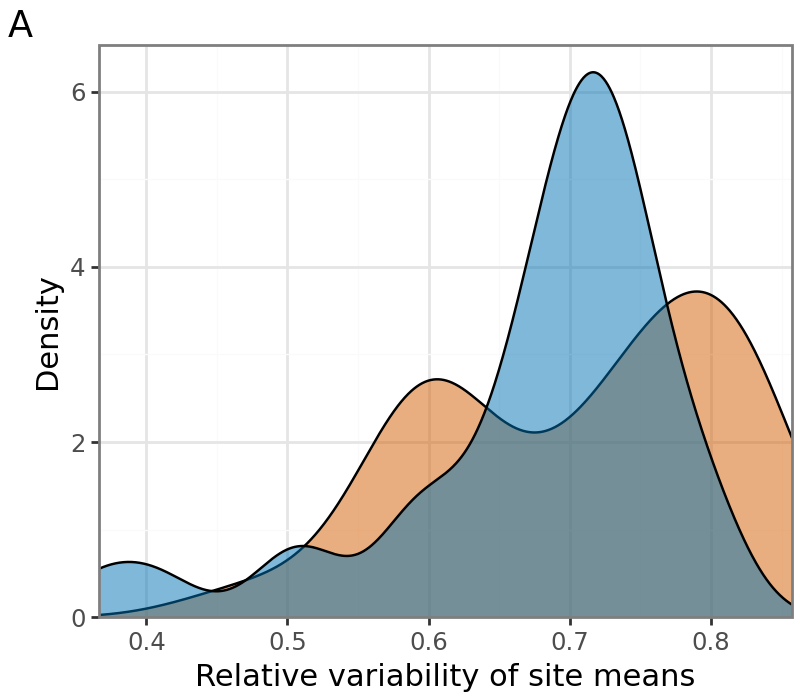

In [4]:
p1 = (
    pln.ggplot(res, pln.aes(x='RVSM', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_density(alpha=0.5)
    + pln.scale_y_continuous(expand = (0, 0, 0.05, 0))
    + pln.scale_x_continuous(expand = (0, 0, 0.0, 0.0))
    + pln.theme_bw()
    + pln.labs(
        x='Relative variability of site means',
        y='Density',
        tag='A')
    + pln.theme(
        legend_position='none',
        figure_size=(4, 3.5))
    )

p1

# Variation within site

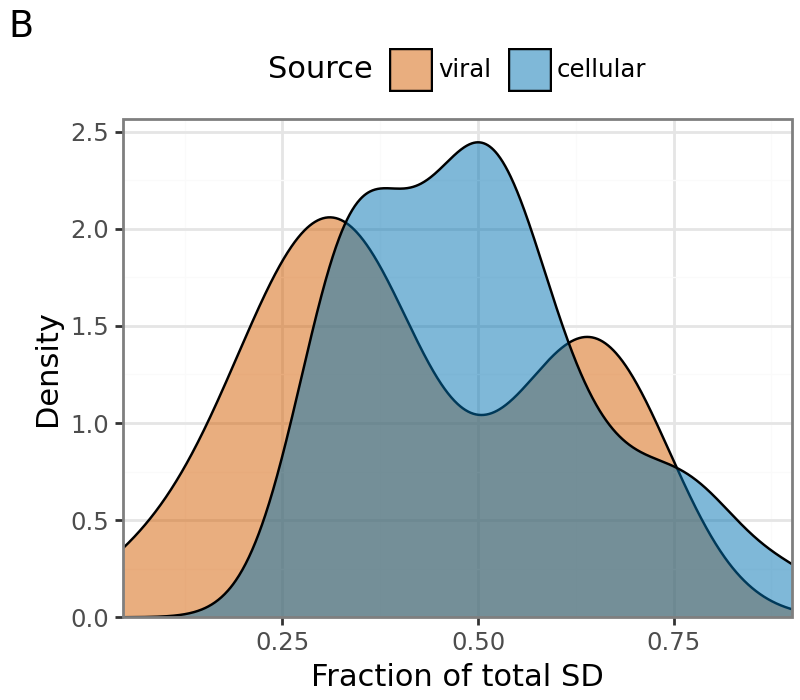

In [5]:
p2 = (
    pln.ggplot(res, pln.aes(x='fractionSD', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_density(alpha=0.5)
    + pln.scale_y_continuous(expand = (0, 0, 0.05, 0))
    + pln.scale_x_continuous(expand = (0, 0, 0.0, 0.0))
    + pln.theme_bw()
    + pln.labs(
        x='Fraction of total SD',
        y='Density',
        tag='B')
    + pln.theme(
        legend_position='top',
        figure_size=(4, 3.5))
    )

p2

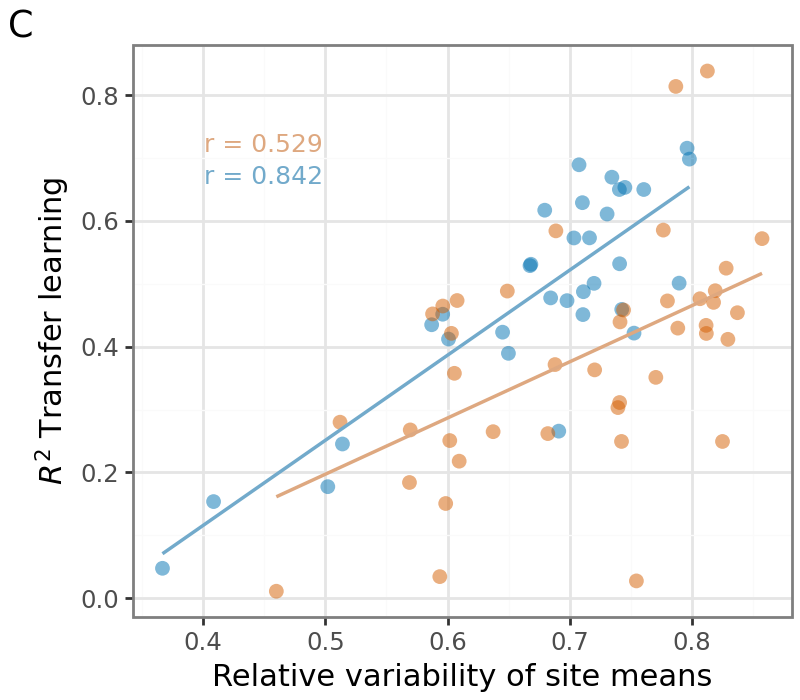

In [6]:
target = 'RVSM'
ann_df = annotation_df(res, target,  x=0.401, y=0.67)
ann_df = ann_df.query('Split == "Pooled Split"')

p3 = (
    pln.ggplot(res, pln.aes(x=target, y='R2_score_test', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point(size=3, alpha=0.5, stroke=0)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#DEA880", "cellular": "#72AACB"})
    + pln.geom_text(data= ann_df , mapping=pln.aes(x=target, y='R2_score_test', label='label', color='Source'), 
                    size=9, ha="left", inherit_aes=False)
    + pln.theme_bw()
    + pln.theme(legend_position='none', figure_size=(4, 3.5))
    + pln.labs(
        y='$R^2$ Transfer learning',
        x= 'Relative variability of site means',
        tag='C')
    )

p3

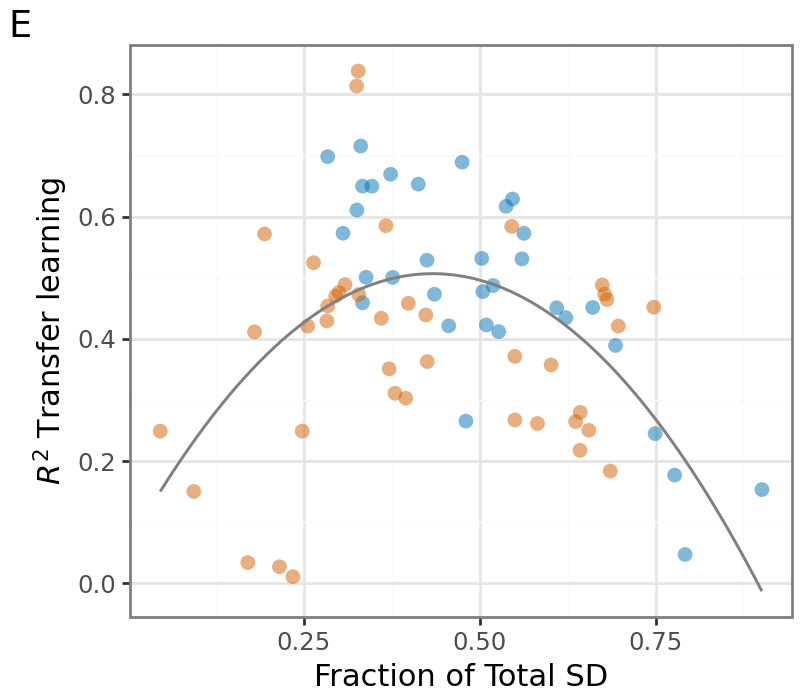

In [7]:
p4 = (
    pln.ggplot(res, pln.aes(x='fractionSD', y='R2_score_test'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point(size=3, alpha=0.5, stroke=0, mapping=pln.aes(fill='Source'))
 
    + pln.geom_smooth(
        method='lm',
        formula='y ~ I(x*x) + x',
        se=False, alpha=1, size=0.6, color='grey'
      )
    + pln.scale_color_manual(values={"viral": "#DEA880", "cellular": "#72AACB"})
    + pln.theme_bw()
    + pln.theme(
        legend_position='none', 
        figure_size=(4, 3.5)
        )
    
    + pln.labs(
        y='$R^2$ Transfer learning',
        x = 'Fraction of Total SD',
        tag='E'
      )
    )

p4

# Correlation between variation within and across sites

In [8]:
def annotation_corr(res, x=0.41, y=0.65):
    corr_data = []
    for source in ["viral", "cellular"]:
        for split in ["Pooled Split", "Site Split"]:
            q = '(Source == @source) & (Split == @split)' 
            corr = res.query(q)['RVSM'].corr(res.query(q)['fractionSD'], method='pearson')
            
            corr_data.append({
                'Source': source,
                'Split': split,
                'correlation': corr,
                'label': f"r = {corr:.03f}"
            })

    ann_df = pd.DataFrame(corr_data)
    ann_df['fractionSD'] = x
    ann_df['RVSM'] = ann_df['Source'].map({'cellular': y, 'viral': y+0.05,})
    return ann_df



ann_df = annotation_corr(res, x=0.7, y=0.77)
ann_df = ann_df.query('Split == "Pooled Split"')
ann_df

,Source,Split,correlation,label,fractionSD,RVSM
0,viral,Pooled Split,-0.603715,r = -0.604,0.7,0.82
2,cellular,Pooled Split,-0.878519,r = -0.879,0.7,0.77


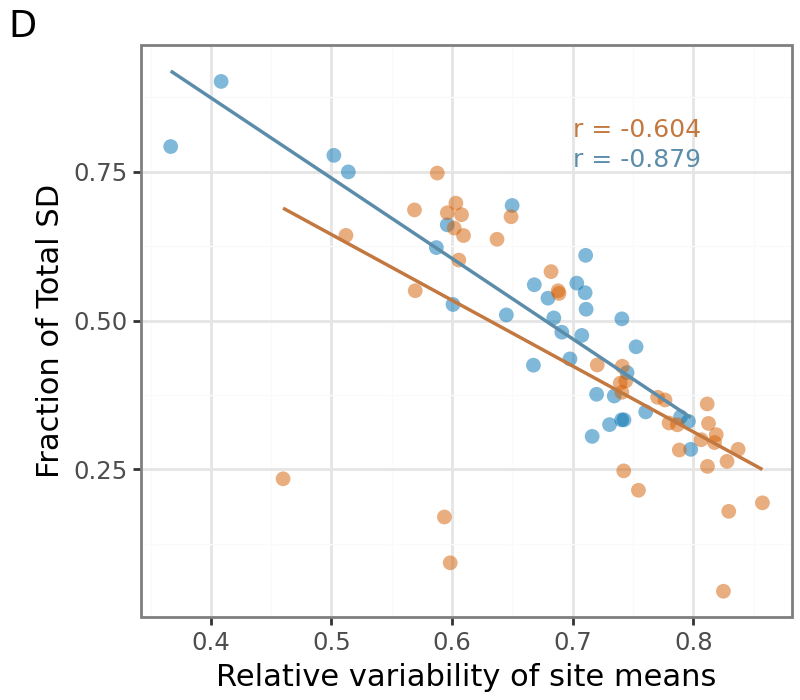

In [9]:
p5 = (
    pln.ggplot(res, pln.aes(x='RVSM', y='fractionSD', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point(size=3, alpha=0.5, stroke=0)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#C2783F", "cellular": "#5B8DAA"})
    + pln.theme_bw()
    + pln.geom_text(data=ann_df, mapping=pln.aes(x='fractionSD', y='RVSM', label='label', color='Source'), 
                    size=9, ha="left", inherit_aes=False)
    + pln.labs(
        y='Fraction of Total SD',
        x='Relative variability of site means',
        tag='D'
        )
    + pln.theme(
        legend_position='none',
        figure_size=(4, 3.5))
        )

p5#.save(filename='../experiments/supp_correlation_fractionSD_RVSE.png', dpi=600) 

# Transfer leanring vs AVG

In [10]:
def read_results(res_dir_path, model_name):
    res = pd.DataFrame()
    for file in os.listdir(res_dir_path):
        if file.endswith('.csv'):
            dataset = file.split('.')[0]
            df = pd.read_csv(os.path.join(res_dir_path, file), index_col=0)
            df['Dataset'] = dataset
            res = pd.concat([res, df], ignore_index=True)
    res['Model'] = model_name
    return res

In [11]:
def load_results(lassoCV_res_dir, AVG_res_dir):
    lassoCV = pd.DataFrame()
    for model in ['esm2_650m']:
        for source in ['viral', 'cellular']:
            for method in ['pool_split']:
                res_dir_path = f'{lassoCV_res_dir}/{model}/{source}/{method}/'
                res = read_results(res_dir_path, 'ESM-2 650M')
                res['Source'] = source
                res['Split'] = method
                res['Model'] = model
                
                lassoCV = pd.concat([lassoCV, res], ignore_index=True)

    res_avg = pd.DataFrame()
    for source in ['viral', 'cellular']:
        for method in ['pool_split']:
            res_dir_path = f'{AVG_res_dir}/{source}/{method}/'
            res = read_results(res_dir_path, 'AVG')
            res['Source'] = source
            res['Split'] = method
            res_avg = pd.concat([res_avg, res], ignore_index=True)


    res = pd.concat([res_avg, lassoCV.drop('num_nonzero_coefs', axis=1)])
    res = res.groupby(['Model', 'Dataset', 'Source', 'Split'], as_index=False).mean()
    res = res.query('Split == "pool_split"')
    rename_map = {
            'esm2_viral_650m_MP15_partial':'esm2_viral_partial', 
            'esm2_viral_650m_MP15':'esm2_viral_full',
            'pool_split':'pooled',
            'site_split':'site',
    }
    res.replace(rename_map, inplace=True)

    res_pivot = pd.pivot_table(res, index=['Dataset', 'Source', 'Split'], columns='Model', values='R2_score_test').reset_index()

    return res_pivot 

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:372: PlotnineWarning: geom_point : Removed 1 rows containing missing values.


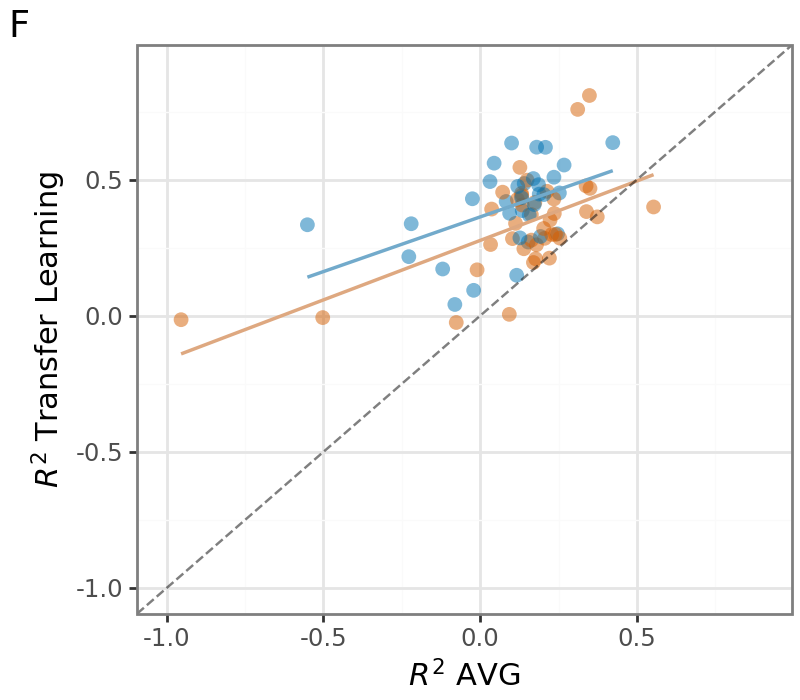

In [12]:
resSTD07 = load_results('../experiments/lassoCV_STD0.7_filtered', '../experiments/AVG_STD0.7_filtered/')
resSTD07['Source'] = pd.Categorical(resSTD07['Source'], categories=['viral', 'cellular'])

p6 = (
    pln.ggplot(resSTD07, pln.aes(y='esm2_650m', x='AVG', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point(size=3, alpha=0.5, stroke=0)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#DEA880", "cellular": "#72AACB"})
    + pln.theme_bw(11)
    + pln.geom_abline(intercept=0, alpha=0.5, linetype='dashed')
    + pln.theme(
        figure_size=(4,3.5),
        legend_position='none',
        legend_text=pln.element_text(size=11),
        legend_title=pln.element_blank()
    )
    + pln.ylim(-1, 0.9)
    + pln.xlim(-1, 0.9)
    + pln.labs(
        y="$R^2$ Transfer Learning",
        x="$R^2$ AVG",
        tag='F'
    )
    )

p6

# composition

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:372: PlotnineWarning: geom_point : Removed 1 rows containing missing values.


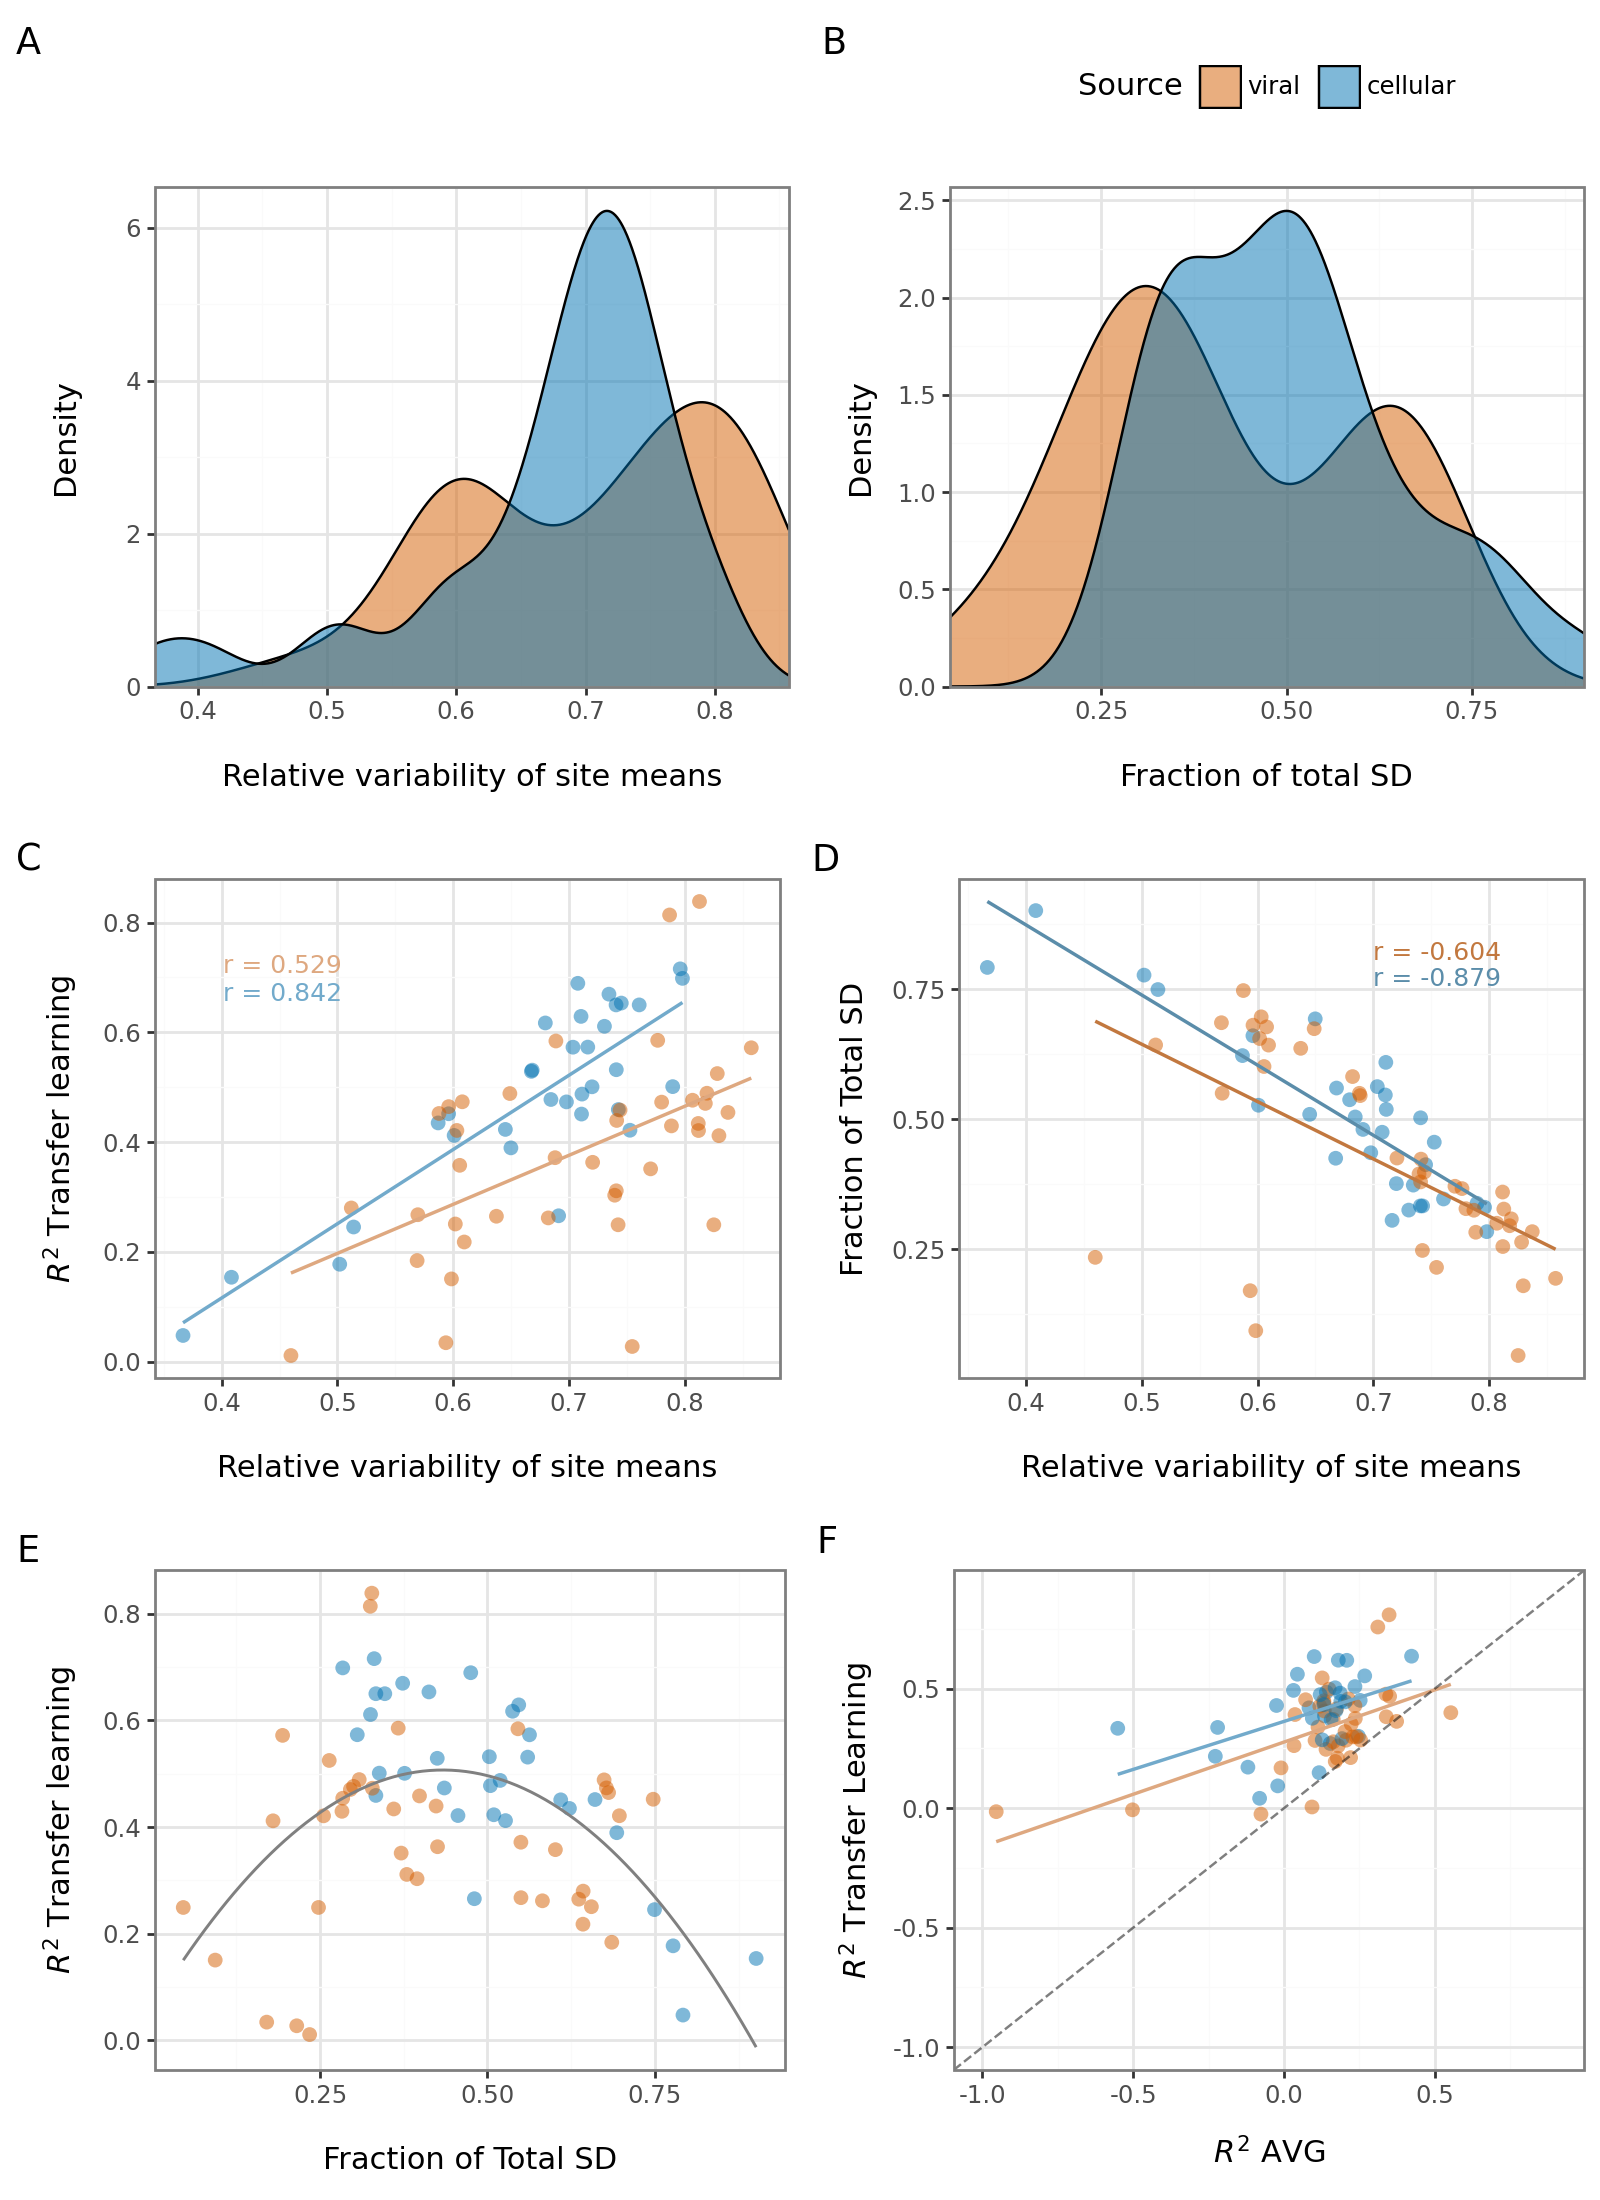

In [13]:
#comp = (p1 | p2) / (p3 | p4)
comp = (p1 | p2) / (p3 | p5) / (p4 | p6)
plot = comp + pln.theme(figure_size=(8, 11))
#plot.save(filename='../experiments/comp3_site_variation6.png', dpi=600)
plot

# Site Split

## Coverage

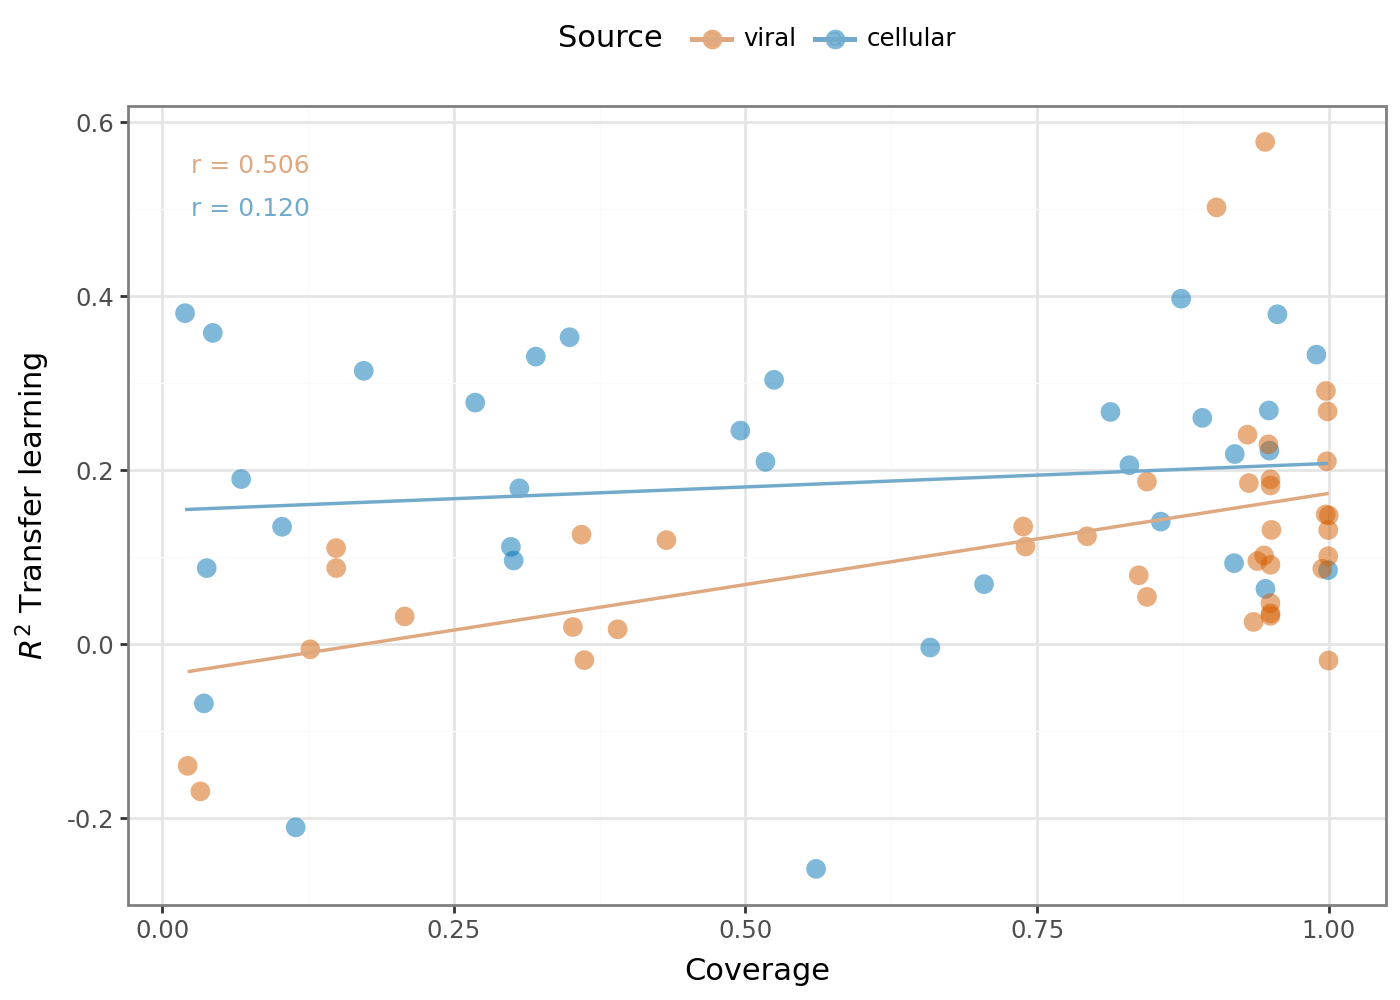

In [4]:
target = 'coverage'
res_SS = lassocv.query('Split in @s')
ann_df = annotation_df(res_SS, target,  x=0.025, y=0.5)
ann_df = ann_df.query('Split == "Site Split"')

cov = (
    pln.ggplot(res_SS, pln.aes(x=target, y='R2_score_test', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point(size=4, alpha=0.5, stroke=0)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#DEA880", "cellular": "#72AACB"})
    + pln.geom_text(data= ann_df , mapping=pln.aes(x=target, y='R2_score_test', label='label', color='Source'), 
                    size=9, ha="left", inherit_aes=False)
    + pln.theme_bw()
    + pln.theme(legend_position='top', figure_size=(7, 5))
    + pln.labs(
        y='$R^2$ Transfer learning',
        x= 'Coverage',
        tag='')
    )

#cov.save(filename='../experiments/fig5_coverage_corr.png', dpi=600)
cov

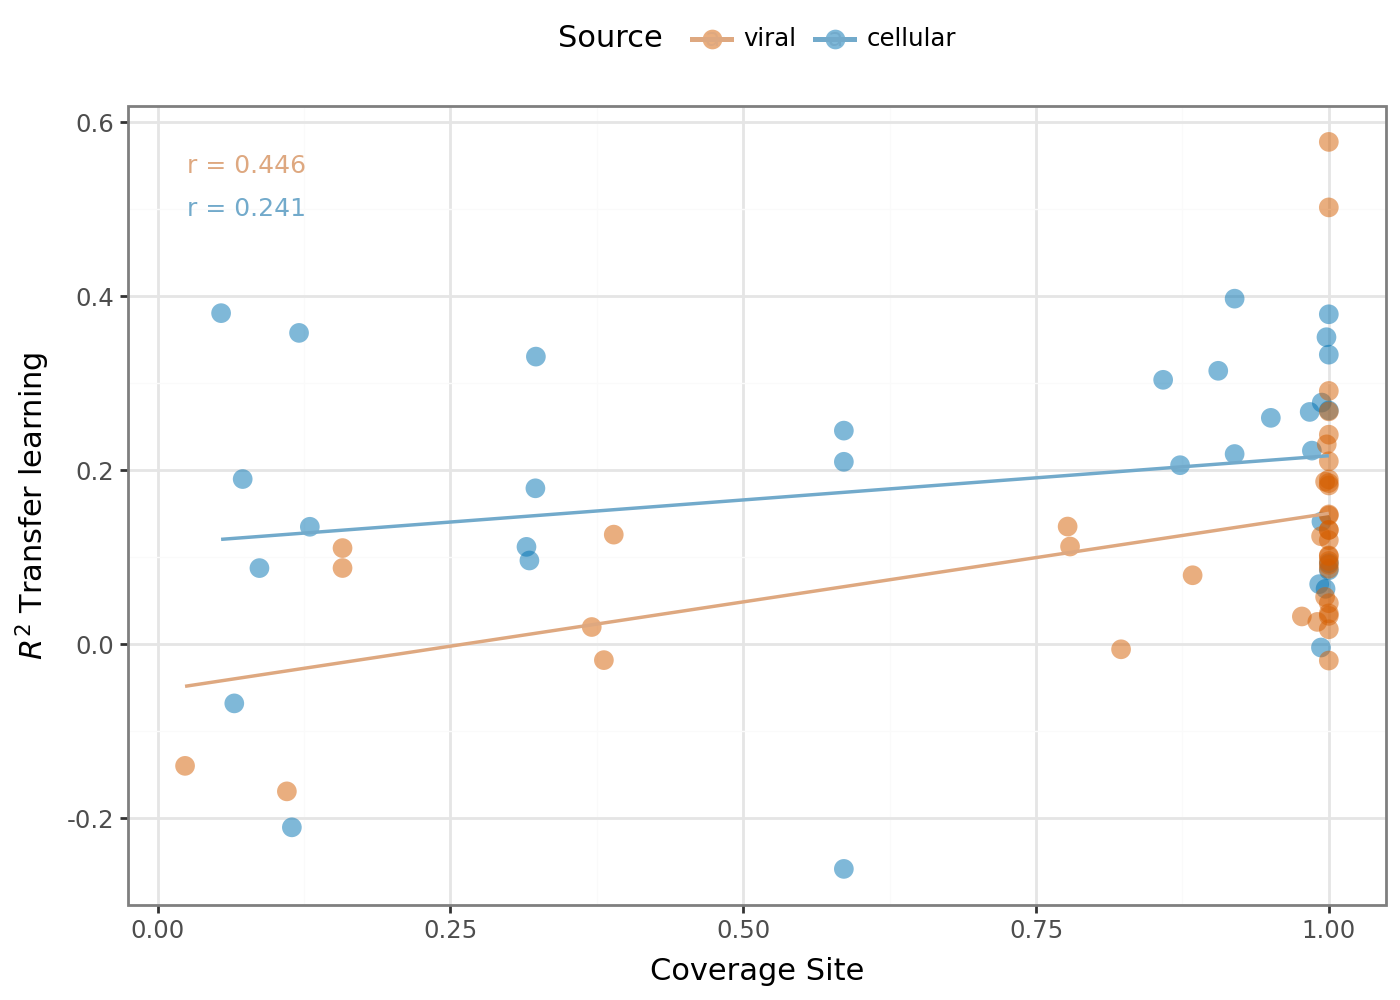

In [5]:
target = 'coverage_site'
res_SS = lassocv.query('Split in @s')
ann_df = annotation_df(res_SS, target,  x=0.025, y=0.5)
ann_df = ann_df.query('Split == "Site Split"')

covS = (
    pln.ggplot(res_SS, pln.aes(x=target, y='R2_score_test', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point(size=4, alpha=0.5, stroke=0)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#DEA880", "cellular": "#72AACB"})
    + pln.geom_text(data= ann_df , mapping=pln.aes(x=target, y='R2_score_test', label='label', color='Source'), 
                    size=9, ha="left", inherit_aes=False)
    + pln.theme_bw()
    + pln.theme(legend_position='top', figure_size=(7, 5))
    + pln.labs(
        y='$R^2$ Transfer learning',
        x= 'Coverage Site',
        tag='')
    )

#covS.save(filename='../experiments/fig5_coverage_corr.png', dpi=600)
covS

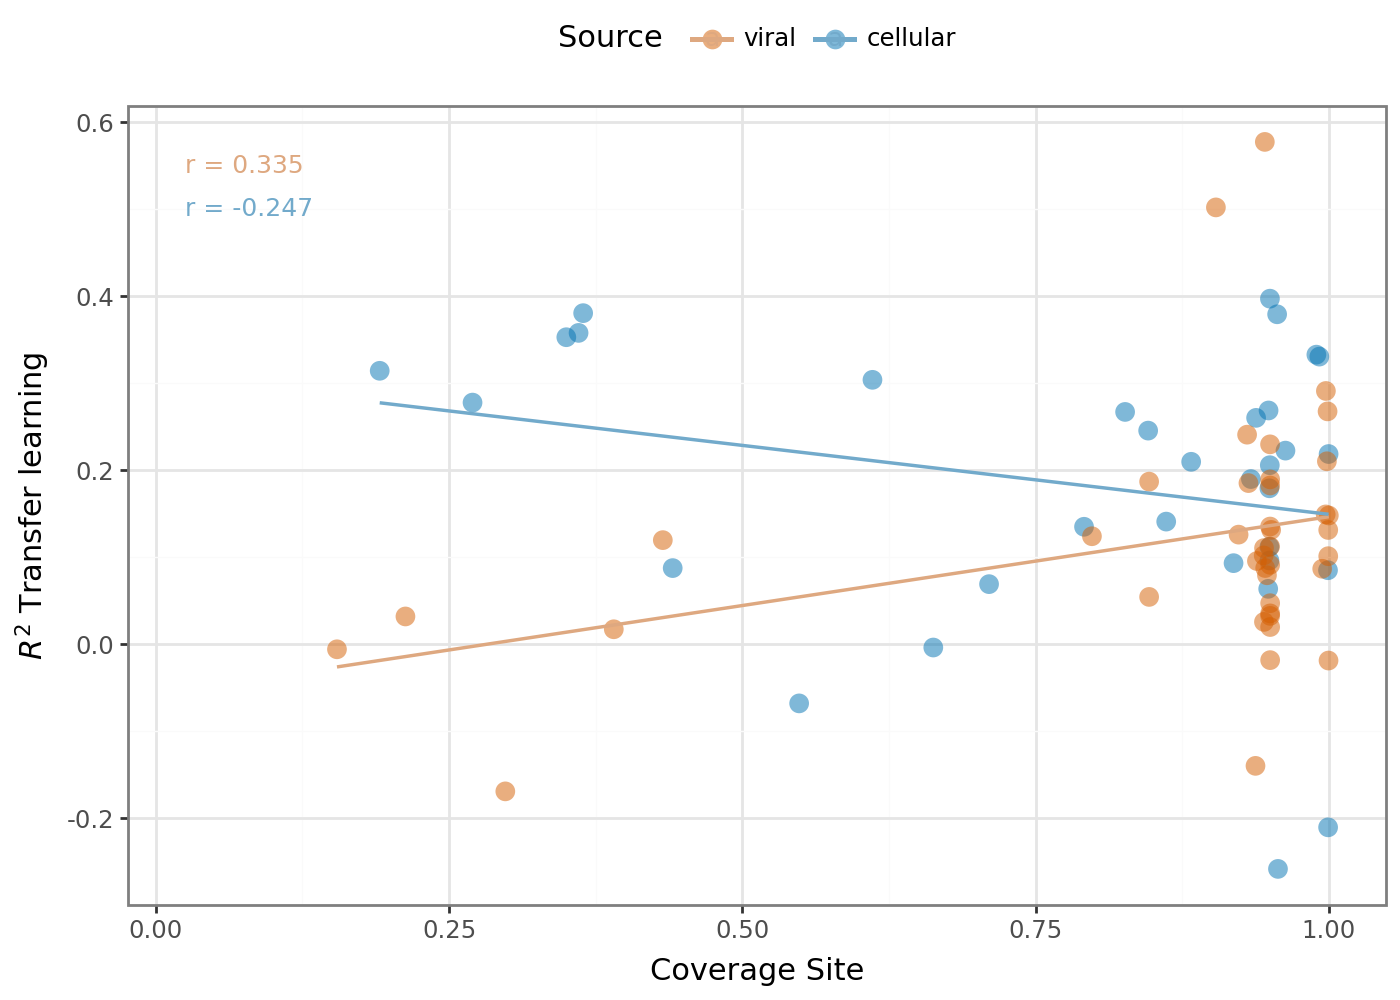

In [6]:
target = 'coverage_within'
res_SS = lassocv.query('Split in @s')
ann_df = annotation_df(res_SS, target,  x=0.025, y=0.5)
ann_df = ann_df.query('Split == "Site Split"')

covW = (
    pln.ggplot(res_SS, pln.aes(x=target, y='R2_score_test', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point(size=4, alpha=0.5, stroke=0)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#DEA880", "cellular": "#72AACB"})
    + pln.geom_text(data= ann_df , mapping=pln.aes(x=target, y='R2_score_test', label='label', color='Source'), 
                    size=9, ha="left", inherit_aes=False)
    + pln.theme_bw()
    + pln.theme(legend_position='top', figure_size=(7, 5))
    + pln.labs(
        y='$R^2$ Transfer learning',
        x= 'Coverage Site',
        tag='')
    )

#covW.save(filename='../experiments/fig5_coverage_corr.png', dpi=600)
covW